# Skenario 3 CNN-LSTM + Embedding Layer (Split 70/30)

| Parameter | Detail |
|-----------|--------|
| **Algoritma** | CNN + LSTM Hybrid |
| **Ekstraksi Fitur** | Keras Trainable Embedding Layer |
| **Pembagian Data** | 70% Train / 30% Test |

## Setup & Load

In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn -q

In [2]:
import numpy as np, pandas as pd, os, pickle, json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import tensorflow as tf
from tensorflow.keras.models import  Model, load_model
from tensorflow.keras.layers import (Dense, LSTM, Dropout,
                                      Embedding, SpatialDropout1D,
                                      Conv1D, MaxPooling1D, GlobalMaxPooling1D,
                                      BatchNormalization, Input, concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import warnings; warnings.filterwarnings('ignore')

tf.random.set_seed(42); np.random.seed(42)
os.makedirs('models/scheme3', exist_ok=True)
os.makedirs('reports', exist_ok=True)

In [3]:
df = pd.read_csv('data/processed_data.csv')
LABEL_NAMES = ['Negatif', 'Netral', 'Positif']

X = df['cleaned_text'].astype(str).values
y = df['label'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Pembagian Data (70/30):")
print(f"Train : {len(X_train_raw):}")
print(f"Test  : {len(X_test_raw):}")

Pembagian Data (70/30):
Train : 10500
Test  : 4500


## Ekstrasi Fitur

In [4]:
VOCAB_SIZE  = len(set(' '.join(X_train_raw).split()))
MAX_SEQ_LEN = 100
EMBED_DIM   = 128

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_raw),
                             maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test_raw),
                             maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat  = to_categorical(y_test, num_classes=3)


print(f"Sequences: train={X_train_seq.shape}, test={X_test_seq.shape}")
print(f"Vocabulary: {len(tokenizer.word_index):,} kata unik")

Sequences: train=(10500, 100), test=(4500, 100)
Vocabulary: 6,674 kata unik


In [5]:
with open('models/scheme3/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [6]:
from tensorflow.keras.regularizers import l2

def build_cnn_lstm_model(vocab_size, embed_dim, seq_len, num_classes=3):
    inputs = Input(shape=(seq_len,), name='Input')

    x = Embedding(vocab_size + 1, embed_dim,
                  input_length=seq_len,
                  trainable=True, name='Embedding_Layer')(inputs)
    x = SpatialDropout1D(0.3)(x)

    conv1 = Conv1D(128, kernel_size=3, activation='relu',
                   padding='same', kernel_regularizer=l2(0.001))(x)
    conv1 = BatchNormalization()(conv1)
    conv1 = MaxPooling1D(pool_size=2)(conv1)
    conv1 = Dropout(0.3)(conv1)

    conv2 = Conv1D(64, kernel_size=5, activation='relu',
                   padding='same', kernel_regularizer=l2(0.001))(x)
    conv2 = BatchNormalization()(conv2)
    conv2 = MaxPooling1D(pool_size=2)(conv2)

    lstm_out = LSTM(128, return_sequences=False,
                    kernel_regularizer=l2(0.001),
                    name='LSTM_Layer')(conv1)
    lstm_out = Dropout(0.4)(lstm_out)

    cnn_out = GlobalMaxPooling1D()(conv2)

    merged = concatenate([lstm_out, cnn_out])
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(merged)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax', name='Output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='CNN_LSTM_Embedding')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn_lstm_model(VOCAB_SIZE, EMBED_DIM, MAX_SEQ_LEN)
model.summary()

Model: "CNN_LSTM_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding_Layer     │ (None, 100, 128)  │    854,272 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 100, 128)  │          0 │ Embedding_Layer[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 100, 128)  │     49,280 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 100, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 50, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 100, 64)   │     41,024 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 50, 128)   │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_Layer (LSTM)   │ (None, 128)       │    131,584 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ LSTM_Layer[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ max_pooling1d_1[… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     24,704 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 3)         │        195 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 1,110,595 (4.24 MB)

 Trainable params: 1,109,955 (4.23 MB)

 Non-trainable params: 640 (2.50 KB)

## Training

In [7]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('models/scheme3/best_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train_seq, y_train_cat,
    epochs=50, batch_size=32,
    validation_split = 0.15,
    callbacks=callbacks, verbose=1
)
print("Training selesai!")

Epoch 1/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.5067 - loss: 1.5944 - val_accuracy: 0.3403 - val_loss: 2.3037 - learning_rate: 0.0010
Epoch 2/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7675 - loss: 0.9752 - val_accuracy: 0.5537 - val_loss: 1.1966 - learning_rate: 0.0010
Epoch 3/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8692 - loss: 0.6779 - val_accuracy: 0.8635 - val_loss: 0.6593 - learning_rate: 0.0010
Epoch 4/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9095 - loss: 0.5298 - val_accuracy: 0.8635 - val_loss: 0.6379 - learning_rate: 0.0010
Epoch 5/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9378 - loss: 0.4173 - val_accuracy: 0.8743 - val_loss: 0.6228 - learning_rate: 0.0010
Epoch 6/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9477 - loss: 0.3483 - val_accuracy: 0.8724 - val_loss: 0.6444 - learning_rate: 0.0010
Epoch 7/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9522 - loss: 0

## Evaluasi

In [8]:
model = load_model('models/scheme3/best_model.keras')
y_pred = np.argmax(model.predict(X_test_seq), axis=1)

train_loss, train_acc = model.evaluate(X_train_seq, y_train_cat, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test_seq,  y_test_cat,  verbose=0)

print(f"HASIL EVALUASI")
print(f"Training Accuracy : {train_acc*100:.2f}%")
print(f"Testing  Accuracy : {test_acc*100:.2f}%")
print(f"F1-Score (macro)  : {f1_score(y_test, y_pred, average='macro')*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
HASIL EVALUASI
Training Accuracy : 97.49%
Testing  Accuracy : 87.89%
F1-Score (macro)  : 87.77%
              precision    recall  f1-score   support

     Negatif       0.82      0.85      0.84      1500
      Netral       0.94      0.99      0.97      1500
     Positif       0.87      0.79      0.83      1500

    accuracy                           0.88      4500
   macro avg       0.88      0.88      0.88      4500
weighted avg       0.88      0.88      0.88      4500



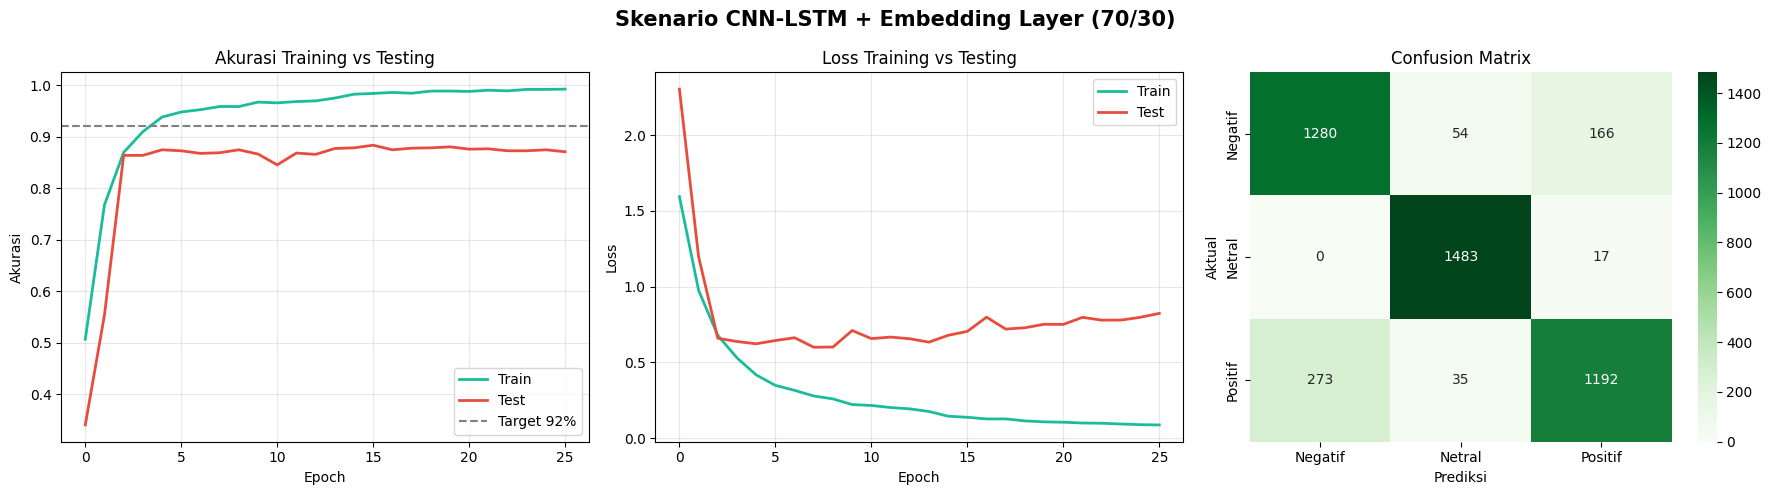

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Skenario CNN-LSTM + Embedding Layer (70/30)', fontsize=15, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train', color='#1abc9c', lw=2)
axes[0].plot(history.history['val_accuracy'], label='Test',  color='#e74c3c', lw=2)
axes[0].axhline(0.92, color='gray', linestyle='--', label='Target 92%')
axes[0].set_title('Akurasi Training vs Testing'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='#1abc9c', lw=2)
axes[1].plot(history.history['val_loss'], label='Test',  color='#e74c3c', lw=2)
axes[1].set_title('Loss Training vs Testing'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
axes[2].set_title('Confusion Matrix')
axes[2].set_ylabel('Aktual'); axes[2].set_xlabel('Prediksi')

plt.tight_layout()
plt.show()

In [10]:
results_s3 = {
    'scheme': 'Skema 3',
    'algorithm': 'CNN-LSTM',
    'feature': 'Embedding Layer',
    'split': '70/30',
    'train_acc': round(train_acc*100,2),
    'test_acc': round(test_acc*100,2),
    'f1_macro': round(f1_score(y_test, y_pred, average='macro')*100,2)
}
with open('reports/scheme3_results.json', 'w') as f:
    json.dump(results_s3, f, indent=2)

## Perbandingan skenario 1 2 3

In [11]:
import glob
all_results = []
for f in sorted(glob.glob('reports/scheme*_results.json')):
    with open(f) as fp:
        all_results.append(json.load(fp))

df_recap = pd.DataFrame(all_results)
df_recap.columns = ['Skema','Algoritma','Fitur','Split','Train Acc','Test Acc','F1 Macro']

print("Perbandingan Hasil")
print(df_recap.to_string(index=False))

Perbandingan Hasil
  Skema Algoritma           Fitur Split  Train Acc  Test Acc  F1 Macro
Skema 1      LSTM          TF-IDF 80/20      97.50     86.00     85.85
Skema 2    BiLSTM        Word2Vec 80/20      92.47     88.37     88.34
Skema 3  CNN-LSTM Embedding Layer 70/30      97.49     87.89     87.77
